In [2]:
import pandas as pd
import numpy as np
import time
import os
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load the cleaned dataset
# Ensure the 'id' column is parsed as a datetime and set as the index
df = pd.read_csv('data/train_cleaned.csv', parse_dates=['id'], index_col='id')

print("Dataset loaded successfully.")
print(df.info())

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40991 entries, 2020-01-01 00:00:00 to 2024-09-03 22:00:00
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   valeur_NO2           40991 non-null  float64
 1   valeur_CO            40991 non-null  float64
 2   valeur_O3            40991 non-null  float64
 3   valeur_PM10          40991 non-null  float64
 4   valeur_PM25          40991 non-null  float64
 5   hour                 40991 non-null  int64  
 6   dayofweek            40991 non-null  int64  
 7   month                40991 non-null  int64  
 8   dayofyear            40991 non-null  int64  
 9   is_weekend           40991 non-null  int64  
 10  is_holiday           40991 non-null  int64  
 11  temperature          40991 non-null  float64
 12  relative_humidity    40991 non-null  int64  
 13  wind_speed           40991 non-null  float64
 14  precipitation        4

Changing weather data to just use averages

In [3]:
# --- Create Smoothed Weather Features Based on 2-Week Rolling Window Across All Years ---
print("Creating smoothed weather features based on 2-week rolling window at same hour (across all years)...")

# Define the cutoff date for validation set
validation_start_date = pd.to_datetime('2024-08-01')

# Create a copy to work with
df_smoothed = df.copy()

# Ensure we have the helper columns (don't duplicate if they already exist)
if 'hour' not in df_smoothed.columns:
    df_smoothed['hour'] = df_smoothed.index.hour
if 'dayofyear' not in df_smoothed.columns:
    df_smoothed['dayofyear'] = df_smoothed.index.dayofyear

# Filter historical data (before validation set)
df_historical = df_smoothed[df_smoothed.index < validation_start_date].copy()

# For each weather column, create smoothed values
for weather_col in ['temperature', 'relative_humidity', 'wind_speed', 'precipitation', 'wind_direction', 'shortwave_radiation']:
    print(f"Processing {weather_col}...")
    
    # Group by hour and dayofyear, then calculate mean across all years
    climatology_map = df_historical.groupby(['hour', 'dayofyear'])[weather_col].mean()
    
    # Create a DataFrame for rolling operation
    climatology_df = climatology_map.reset_index()
    
    # For each hour separately, compute rolling mean over dayofyear
    smoothed_climatology = []
    for hour in range(24):
        hour_data = climatology_df[climatology_df['hour'] == hour].copy()
        hour_data = hour_data.sort_values('dayofyear')
        
        # Handle year wraparound: duplicate edges
        # Append first 7 days to end and last 7 days to beginning
        top_days = hour_data[hour_data['dayofyear'] <= 7].copy()
        top_days['dayofyear'] = top_days['dayofyear'] + 366
        
        bottom_days = hour_data[hour_data['dayofyear'] >= 359].copy()
        bottom_days['dayofyear'] = bottom_days['dayofyear'] - 366
        
        # Concatenate: bottom_days, hour_data, top_days
        extended_data = pd.concat([bottom_days, hour_data, top_days]).sort_values('dayofyear')
        
        # Use rolling window of 15 days (±7 around center)
        extended_data['smoothed'] = extended_data[weather_col].rolling(
            window=15, 
            min_periods=1, 
            center=True
        ).mean()
        
        # Keep only the original days (1-366)
        hour_data_smoothed = extended_data[(extended_data['dayofyear'] >= 1) & 
                                           (extended_data['dayofyear'] <= 366)].copy()
        
        smoothed_climatology.append(hour_data_smoothed[['hour', 'dayofyear', 'smoothed']])
    
    # Combine all hours
    smoothed_climatology_df = pd.concat(smoothed_climatology, ignore_index=True)
    smoothed_climatology_df.rename(columns={'smoothed': f'{weather_col}_smoothed'}, inplace=True)
    
    # Map smoothed values back using direct lookup (avoiding merge issues)
    # Create a lookup dictionary
    lookup = smoothed_climatology_df.set_index(['hour', 'dayofyear'])[f'{weather_col}_smoothed'].to_dict()
    
    # Apply lookup to create smoothed column
    df_smoothed[f'{weather_col}_smoothed'] = df_smoothed.apply(
        lambda row: lookup.get((row['hour'], row['dayofyear']), 
                               df_historical[weather_col].mean()), 
        axis=1
    )
    
    # Replace original column with smoothed values
    df_smoothed[weather_col] = df_smoothed[f'{weather_col}_smoothed']
    df_smoothed.drop(columns=[f'{weather_col}_smoothed'], inplace=True)

# Clean up helper columns if they didn't exist before
# (Only if df didn't originally have them - check original df)
if 'hour' not in df.columns:
    df_smoothed.drop(columns=['hour'], inplace=True)
if 'dayofyear' not in df.columns:
    df_smoothed.drop(columns=['dayofyear'], inplace=True)

print("Smoothed weather features created successfully!")

# Show comparison (use .values to avoid index mismatch)
print(f"\nOriginal vs Smoothed comparison for temperature (first 5 rows):")
comparison = pd.DataFrame({
    'date': df.index[:10],
    'original_temp': df['temperature'].iloc[:10].values,
    'smoothed_temp': df_smoothed['temperature'].iloc[:10].values
})
print(comparison)
print(pd.DataFrame({
    'date': df.index[-10:],
    'original_temp': df['temperature'].iloc[-10:].values,
    'smoothed_temp': df_smoothed['temperature'].iloc[-10:].values
}))
# Update df to use the smoothed version
df = df_smoothed.copy()

Creating smoothed weather features based on 2-week rolling window at same hour (across all years)...
Processing temperature...
Processing relative_humidity...
Processing wind_speed...
Processing precipitation...
Processing wind_direction...
Processing shortwave_radiation...
Smoothed weather features created successfully!

Original vs Smoothed comparison for temperature (first 5 rows):
                 date  original_temp  smoothed_temp
0 2020-01-01 00:00:00            0.8       6.929000
1 2020-01-01 01:00:00           -0.2       6.738333
2 2020-01-01 02:00:00            2.5       6.849667
3 2020-01-01 03:00:00            2.0       6.766333
4 2020-01-01 04:00:00            1.8       6.706333
5 2020-01-01 05:00:00            2.1       6.666667
6 2020-01-01 06:00:00            2.0       6.675333
7 2020-01-01 07:00:00            2.2       6.569333
8 2020-01-01 08:00:00            2.3       6.519667
9 2020-01-01 09:00:00            2.2       6.438333
                 date  original_temp  sm

### Splitting, scaling

In [4]:
# --- 1. Define Features (X) and Targets (y) ---

# The targets are the 5 pollutant columns we want to predict
TARGET_COLS = ['valeur_NO2', 'valeur_CO', 'valeur_O3', 'valeur_PM10', 'valeur_PM25']

# The features are all other columns (original time features + all new lagged features)
# We drop the original pollutant columns from our feature set
X = df.drop(columns=TARGET_COLS)
y = df[TARGET_COLS]


# --- 2. Create the Time-Based Train/Validation Split ---

# We'll use the last month of data as our validation set.
# This simulates the real-world scenario of predicting the future.
validation_size_months = 1
split_date = X.index.max() - pd.DateOffset(months=validation_size_months)

X_train = X[X.index < split_date]
X_val = X[X.index >= split_date]

y_train = y[y.index < split_date]
y_val = y[y.index >= split_date]

print(f"Training set shape:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set shape: X={X_val.shape}, y={y_val.shape}")
print(f"Split date: {split_date}")


# --- 3. Scale the Data ---

# We need one scaler for the features (X) and another for the targets (y)
x_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))

# FIT the scalers on the TRAINING data ONLY
x_scaler.fit(X_train)
y_scaler.fit(y_train)

# TRANSFORM both the training and validation data using the fitted scalers
X_train_scaled = x_scaler.transform(X_train)
X_val_scaled = x_scaler.transform(X_val)

y_train_scaled = y_scaler.transform(y_train)
y_val_scaled = y_scaler.transform(y_val)

print("\nData has been successfully split and scaled.")

Training set shape:   X=(40246, 12), y=(40246, 5)
Validation set shape: X=(745, 12), y=(745, 5)
Split date: 2024-08-03 22:00:00

Data has been successfully split and scaled.


### Reshaping for the LSTM training process

We should finetune the `TIMESTEPS` feature later

In [5]:
# --- Define the sequence length (lookback window) ---
# We'll fix it to 24 hours for this experiment to test model size.
TIMESTEPS = 24

def create_sequences(X, y, timesteps):
    """
    Reshapes the flat data into sequences for an LSTM.
    """
    X_out, y_out = [], []
    # Slide a window of size 'timesteps' over the data
    for i in range(len(X) - timesteps + 1):
        X_out.append(X[i:(i + timesteps)])
        y_out.append(y[i + timesteps - 1])
    return np.array(X_out), np.array(y_out)

# Reshape the training and validation data
X_train_reshaped, y_train_reshaped = create_sequences(X_train_scaled, y_train_scaled, TIMESTEPS)
X_val_reshaped, y_val_reshaped = create_sequences(X_val_scaled, y_val_scaled, TIMESTEPS)


print("--- Data Reshaping Complete ---")
print(f"Original X_train shape: {X_train_scaled.shape}")
print(f"Reshaped X_train shape: {X_train_reshaped.shape} -> [samples, timesteps, features]")
print(f"Reshaped y_train shape: {y_train_reshaped.shape}")
print("-" * 20)
print(f"Original X_val shape: {X_val_scaled.shape}")
print(f"Reshaped X_val shape: {X_val_reshaped.shape}")
print(f"Reshaped y_val shape: {y_val_reshaped.shape}")

--- Data Reshaping Complete ---
Original X_train shape: (40246, 12)
Reshaped X_train shape: (40223, 24, 12) -> [samples, timesteps, features]
Reshaped y_train shape: (40223, 5)
--------------------
Original X_val shape: (745, 12)
Reshaped X_val shape: (722, 24, 12)
Reshaped y_val shape: (722, 5)


In [6]:
output_dir = 'graphs'

### Build, Train, Evaluate model


--- Training Model: 2_LSTM_Medium ---


/Users/felix_myu/Desktop/HEC/paris_air_quality/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,037 (78.27 KB)

 Trainable params: 20,037 (78.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0611 - val_loss: 0.0355
Epoch 2/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0529 - val_loss: 0.0356
Epoch 3/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0517 - val_loss: 0.0346
Epoch 4/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0509 - val_loss: 0.0342
Epoch 5/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0504 - val_loss: 0.0347
Epoch 6/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0501 - val_loss: 0.0342
Epoch 7/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0499 - val_loss: 0.0348
Epoch 8/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0497 - val_loss: 0.0348
Epoch 9/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0496 - val_loss: 0.0347
Epoch 10/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0495 - val_loss: 0.0349
Epoch 11/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0494 - val_loss: 0.0352
Epoch 12/100
629/629 ━━━━━━━━━━━━━━━━━━━━

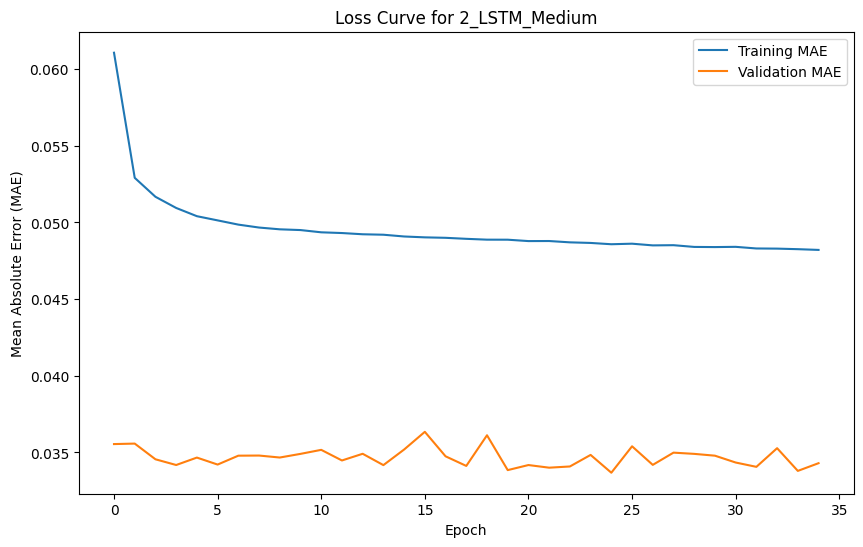


--- Training Model: 3_LSTM_Large ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,837 (284.52 KB)

 Trainable params: 72,837 (284.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0579 - val_loss: 0.0361
Epoch 2/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0524 - val_loss: 0.0356
Epoch 3/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0511 - val_loss: 0.0339
Epoch 4/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0504 - val_loss: 0.0347
Epoch 5/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0500 - val_loss: 0.0346
Epoch 6/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0497 - val_loss: 0.0356
Epoch 7/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0496 - val_loss: 0.0347
Epoch 8/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0495 - val_loss: 0.0373
Epoch 9/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0494 - val_loss: 0.0344
Epoch 10/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0492 - val_loss: 0.0350
Epoch 11/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0492 - val_loss: 0.0356
Epoch 12/100
629/629 ━━━━━━━━━━━━━━━━━

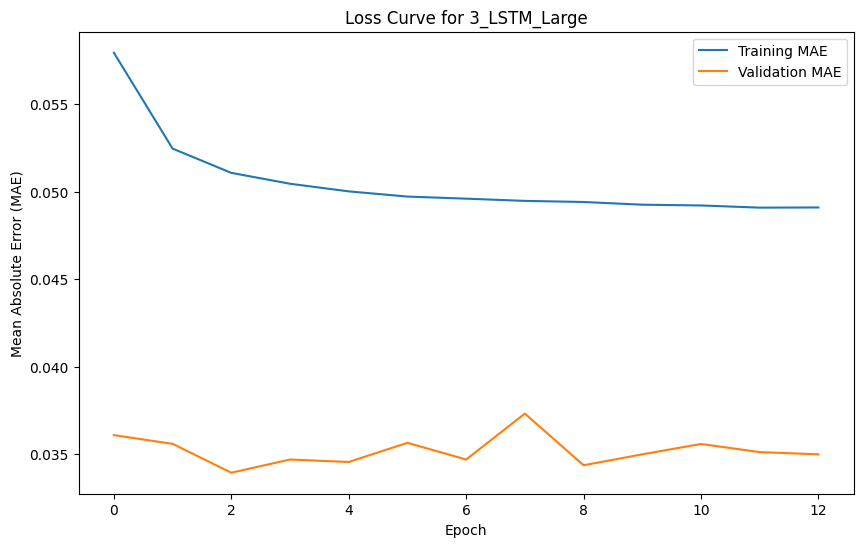


--- Training Model: 4_LSTM_Stacked ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,293 (126.14 KB)

 Trainable params: 32,293 (126.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0601 - val_loss: 0.0363
Epoch 2/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0529 - val_loss: 0.0348
Epoch 3/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0511 - val_loss: 0.0346
Epoch 4/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0505 - val_loss: 0.0350
Epoch 5/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0501 - val_loss: 0.0354
Epoch 6/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0499 - val_loss: 0.0352
Epoch 7/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0498 - val_loss: 0.0343
Epoch 8/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0497 - val_loss: 0.0346
Epoch 9/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0496 - val_loss: 0.0346
Epoch 10/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0494 - val_loss: 0.0349
Epoch 11/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0494 - val_loss: 0.0347
Epoch 12/100
629/629 ━━━━━━━━━━━━━━━━━━━━

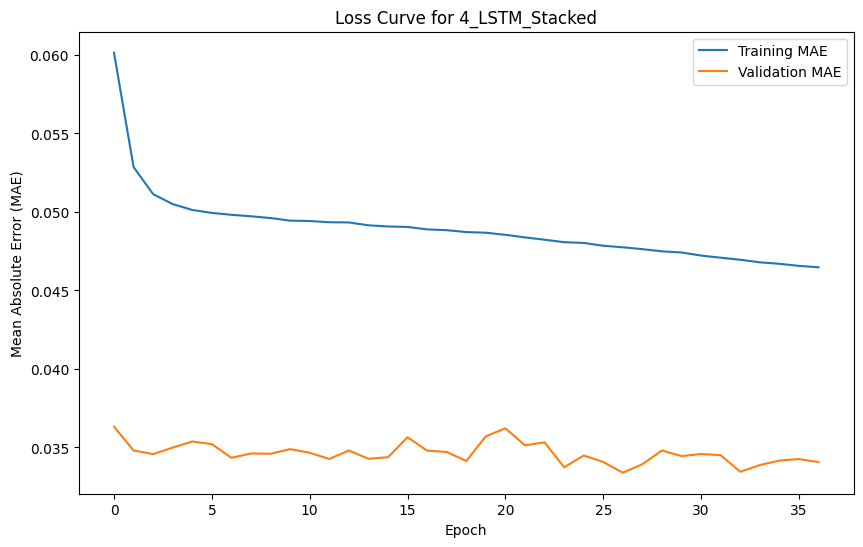

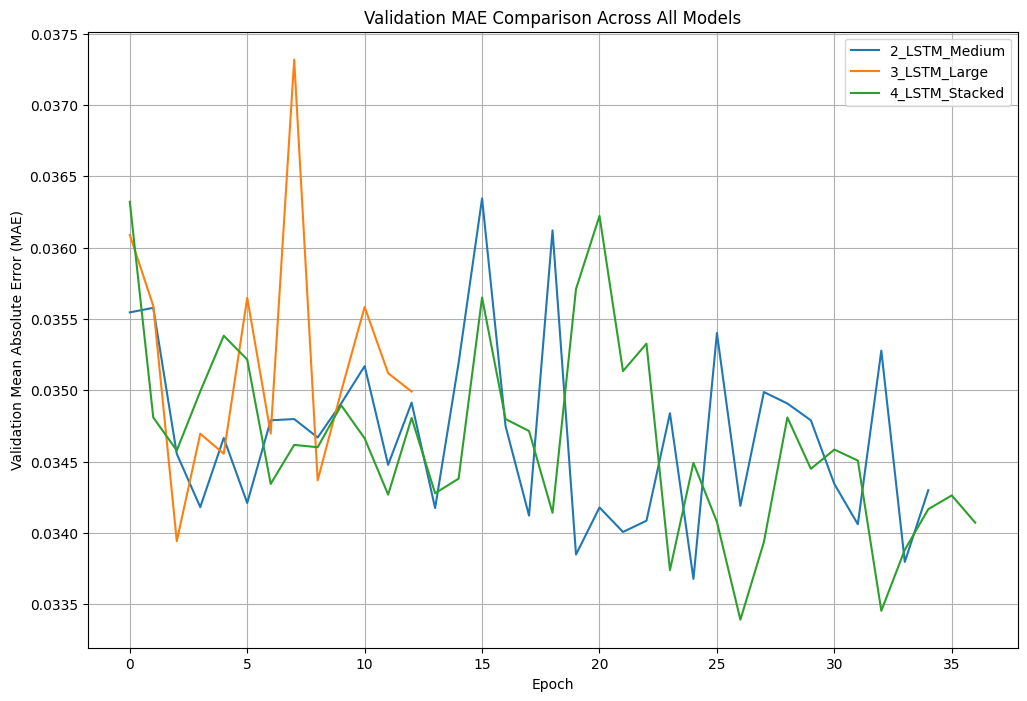

In [7]:
import matplotlib.pyplot as plt
import os

# --- Setup for the Experiment ---
# Create a directory to save our plots
output_dir = 'graphs'
os.makedirs(output_dir, exist_ok=True)

# Define the 5 model architectures of increasing size
model_configs = [
    {'name': '2_LSTM_Medium',  'units': [64],              'dropout': 0.2},
    {'name': '3_LSTM_Large',   'units': [128],             'dropout': 0.2},
    {'name': '4_LSTM_Stacked', 'units': [64, 32],          'dropout': 0.2}
]

# Store results for final comparison
history_log = {}

# --- Training Loop ---
for config in model_configs:
    print(f"\n--- Training Model: {config['name']} ---")
    
    # --- Build the Model ---
    model = Sequential()
    
    # Add LSTM layers based on the config
    for i, units in enumerate(config['units']):
        is_last_lstm = (i == len(config['units']) - 1)
        if i == 0:
            # First layer needs input_shape
            model.add(LSTM(units, return_sequences=not is_last_lstm,
                           input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
        else:
            model.add(LSTM(units, return_sequences=not is_last_lstm))
        model.add(Dropout(config['dropout']))
        
    # Final output layer
    model.add(Dense(y_train_reshaped.shape[1], activation='linear')) # 5 neurons for 5 pollutants

    # --- Compile the Model ---
    # We use 'mae' as the loss because it's our competition metric.
    model.compile(optimizer='adam', loss='mae')
    
    model.summary()
    
    # --- Define Callbacks ---
    # Stop training if validation loss doesn't improve for 10 epochs
    # and restore the weights from the best epoch.
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # --- Train the Model ---
    history = model.fit(
        X_train_reshaped,
        y_train_reshaped,
        epochs=100, # Set a high number, early stopping will find the best
        batch_size=64,
        validation_data=(X_val_reshaped, y_val_reshaped),
        callbacks=[early_stopping],
        verbose=1
    )
    
    # --- Log and Plot Individual Results ---
    history_log[config['name']] = history
    
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training MAE')
    plt.plot(history.history['val_loss'], label='Validation MAE')
    plt.title(f"Loss Curve for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"{config['name']}_loss_curve.png"))
    plt.show()


# --- Final Comparison Plot ---
plt.figure(figsize=(12, 8))
for name, history in history_log.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title('Validation MAE Comparison Across All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'model_comparison.png'))
plt.show()

It seems like all 5 models have quite the same performance, therefore, we shuold pick the second smallest model. Having any more neurons doesn't improve performance, and having any few is not computationally important now. Also, the second best model converged faster and in a more stable way than the smallest one.

### Further finetuning

### Adding weight to more relevant dates

For now we see if this helps predict on validaiton set, so we adapt the weights for august 2024

In [8]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

# --- Setup: Define the fastest hyperparameters from the previous step ---
BEST_LR = 0.001
BEST_BS = 128
TIMESTEPS = 24 # Fixed from our earlier experiment

# --- 1. Create the sample_weight array ---

# The weights correspond to the target (y) values. We need the original y_train index.
# The index for y_train_reshaped corresponds to the y_train index shifted by TIMESTEPS.
y_train_dates = y_train.index[TIMESTEPS-1:]

# Start with a default weight of 1 for all samples
sample_weights = pd.Series(1.0, index=y_train_dates)

# Apply weight 1.5 for July 2024
july_2024_mask = (sample_weights.index.month == 7) & (sample_weights.index.year == 2024)
sample_weights[july_2024_mask] = 1.5

# Apply weight 3.0 for all Augusts (this will overwrite July if needed, which is fine)
august_mask = sample_weights.index.month == 8
sample_weights[august_mask] = 3.0

# Convert the pandas Series to a numpy array for model.fit()
sample_weights_np = sample_weights.to_numpy()

print(f"Sample weights created. Total samples: {len(sample_weights_np)}")
print(f"Number of samples with weight > 1: {(sample_weights_np > 1).sum()}")


# --- 2. Train the two models (Baseline vs. Weighted) ---

results = {}
for model_type in ["Baseline", "Weighted"]:
    print(f"\n{'='*50}")
    print(f"--- TRAINING MODEL: {model_type} ---")
    print(f"{'='*50}")

    # Build the model (same architecture for both)
    model = Sequential()
    model.add(LSTM(units=64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
    model.add(Dropout(0.2))
    model.add(Dense(y_train_reshaped.shape[1], activation='linear'))

    optimizer = Adam(learning_rate=BEST_LR)
    model.compile(optimizer=optimizer, loss='mae')

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    fit_kwargs = {
        'epochs': 100,
        'batch_size': BEST_BS,
        'validation_data': (X_val_reshaped, y_val_reshaped),
        'callbacks': [early_stopping],
        'verbose': 1
    }
    
    # Add the sample_weight parameter ONLY for the weighted model
    if model_type == "Weighted":
        fit_kwargs['sample_weight'] = sample_weights_np

    # Train the model
    history = model.fit(X_train_reshaped, y_train_reshaped, **fit_kwargs)
    
    # Store the best validation score
    best_mae = min(history.history['val_loss'])
    results[model_type] = {'history': history, 'best_mae': best_mae}
    print(f"--- Best Validation MAE for {model_type} model: {best_mae:.5f} ---")

Sample weights created. Total samples: 40223
Number of samples with weight > 1: 3790

--- TRAINING MODEL: Baseline ---
Epoch 1/100


/Users/felix_myu/Desktop/HEC/paris_air_quality/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0635 - val_loss: 0.0359
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0540 - val_loss: 0.0354
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0525 - val_loss: 0.0351
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0518 - val_loss: 0.0359
Epoch 5/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0513 - val_loss: 0.0346
Epoch 6/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0507 - val_loss: 0.0356
Epoch 7/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0504 - val_loss: 0.0356
Epoch 8/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0501 - val_loss: 0.0342
Epoch 9/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0500 - val_loss: 0.0347
Epoch 10/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0498 - val_loss: 0.0348
Epoch 11/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0496 - val_loss: 0.0346
Epoch 12/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/ste

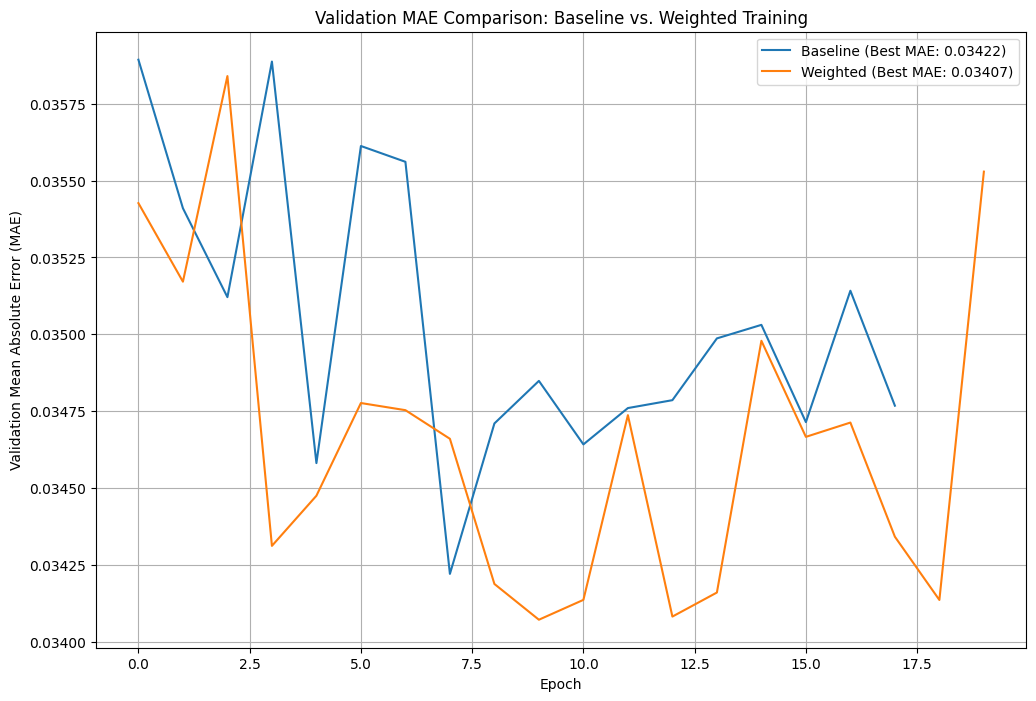

In [9]:
# --- 3. Final Comparison Plot ---
plt.figure(figsize=(12, 8))
for model_type, result in results.items():
    plt.plot(result['history'].history['val_loss'], label=f'{model_type} (Best MAE: {result["best_mae"]:.5f})')

plt.title('Validation MAE Comparison: Baseline vs. Weighted Training')
plt.xlabel('Epoch')
plt.ylabel('Validation Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'weighting_comparison.png'))
plt.show()

Now we will finetune which TIMESTEPS to choose, since our model should be able to absorb more information.


--- TESTING TIMESTEPS = 24 ---
Reshaping data...
New X_train_reshaped shape: (40223, 24, 12)
Starting training for timesteps=24...
Epoch 1/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0620 - val_loss: 0.0364
Epoch 2/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0531 - val_loss: 0.0367
Epoch 3/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0518 - val_loss: 0.0351
Epoch 4/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0511 - val_loss: 0.0350
Epoch 5/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0504 - val_loss: 0.0343
Epoch 6/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0501 - val_loss: 0.0358
Epoch 7/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0499 - val_loss: 0.0341
Epoch 8/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0497 - val_loss: 0.0343
Epoch 9/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0496 - val_loss: 0.0344
Epoch 10/100
629/629 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0495 - val_loss: 0.03

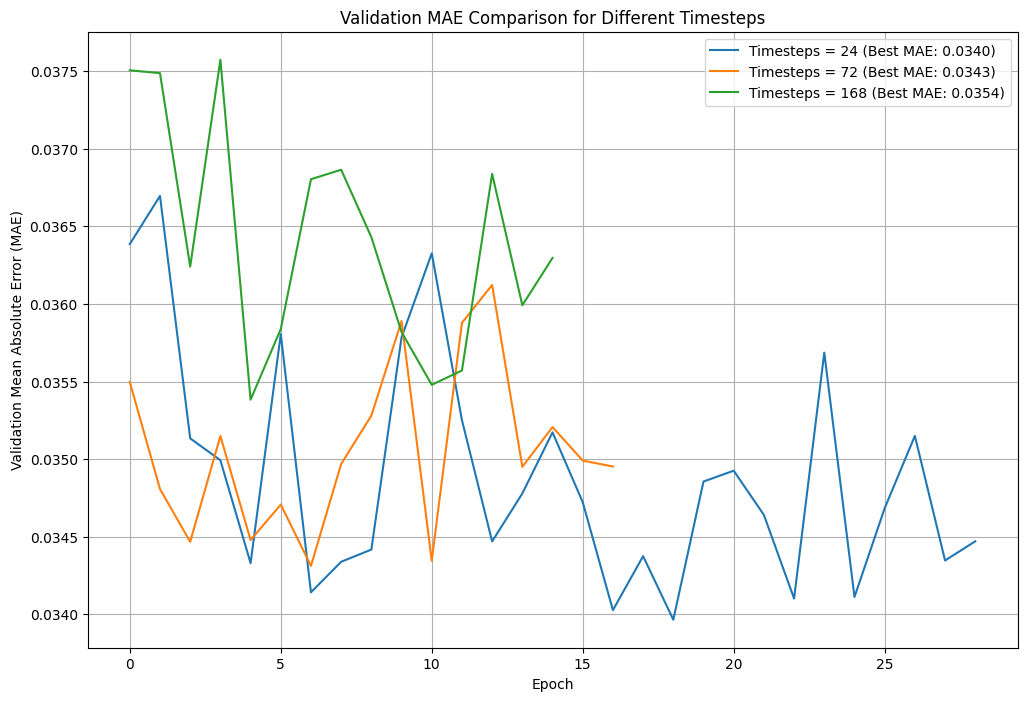

In [10]:
import time

# --- Setup for the Timesteps Tuning Experiment ---

# Define the timesteps values we want to test
timesteps_to_test = [24, 72, 168] # 1 day, 3 days, 1 week

# Define our chosen model architecture
# This stays constant while we change the data's shape
chosen_model_config = {'name': '2_LSTM_Medium', 'units': [64], 'dropout': 0.2}

# Store results for final comparison
timesteps_history_log = {}

# --- Tuning Loop ---
for timesteps in timesteps_to_test:
    print(f"\n{'='*50}")
    print(f"--- TESTING TIMESTEPS = {timesteps} ---")
    print(f"{'='*50}")
    
    start_time = time.time()
    
    # --- 1. Reshape Data for the current timesteps value ---
    print("Reshaping data...")
    X_train_reshaped, y_train_reshaped = create_sequences(X_train_scaled, y_train_scaled, timesteps)
    X_val_reshaped, y_val_reshaped = create_sequences(X_val_scaled, y_val_scaled, timesteps)
    print(f"New X_train_reshaped shape: {X_train_reshaped.shape}")

    # --- 2. Build the Model ---
    model = Sequential()
    model.add(LSTM(
        units=chosen_model_config['units'][0],
        input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])
    ))
    model.add(Dropout(chosen_model_config['dropout']))
    model.add(Dense(y_train_reshaped.shape[1], activation='linear'))

    # --- 3. Compile the Model ---
    model.compile(optimizer='adam', loss='mae')
    
    # --- 4. Define Callbacks ---
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # --- 5. Train the Model ---
    print(f"Starting training for timesteps={timesteps}...")
    history = model.fit(
        X_train_reshaped,
        y_train_reshaped,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_reshaped, y_val_reshaped),
        callbacks=[early_stopping],
        verbose=1
    )
    
    # --- 6. Log Results ---
    timesteps_history_log[timesteps] = history
    end_time = time.time()
    print(f"Training for timesteps={timesteps} finished in {end_time - start_time:.2f} seconds.")


# --- Final Comparison Plot for Timesteps ---
plt.figure(figsize=(12, 8))
for timesteps, history in timesteps_history_log.items():
    # Get the best MAE achieved for the legend
    best_mae = min(history.history['val_loss'])
    plt.plot(history.history['val_loss'], label=f'Timesteps = {timesteps} (Best MAE: {best_mae:.4f})')

plt.title('Validation MAE Comparison for Different Timesteps')
plt.xlabel('Epoch')
plt.ylabel('Validation Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'timesteps_comparison.png'))
plt.show()

Performance does not seem to change with different timesteps so we'll just take the samlles one to accelerate training

In [5]:
# --- Set the chosen timestep value for all subsequent experiments ---
TIMESTEPS = 24

# Reshape the data using our selected 'timesteps' value
X_train_reshaped, y_train_reshaped = create_sequences(X_train_scaled, y_train_scaled, TIMESTEPS)
X_val_reshaped, y_val_reshaped = create_sequences(X_val_scaled, y_val_scaled, TIMESTEPS)

print("Data reshaped with the final TIMESTEPS=24.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")

Data reshaped with the final TIMESTEPS=24.
X_train_reshaped shape: (40055, 24, 67)


Fine-Tuning `learning_rate` and `batch_size`


--- TESTING: LR_0.001-BS_32 ---


/Users/felix_myu/Desktop/HEC/paris_air_quality/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Finished in 126.43 seconds. Best Validation MAE: 0.01398

--- TESTING: LR_0.001-BS_128 ---
Finished in 91.54 seconds. Best Validation MAE: 0.01387

--- TESTING: LR_0.0005-BS_32 ---
Finished in 122.85 seconds. Best Validation MAE: 0.01380

--- TESTING: LR_0.0005-BS_128 ---
Finished in 149.15 seconds. Best Validation MAE: 0.01376


NameError: name 'output_dir' is not defined

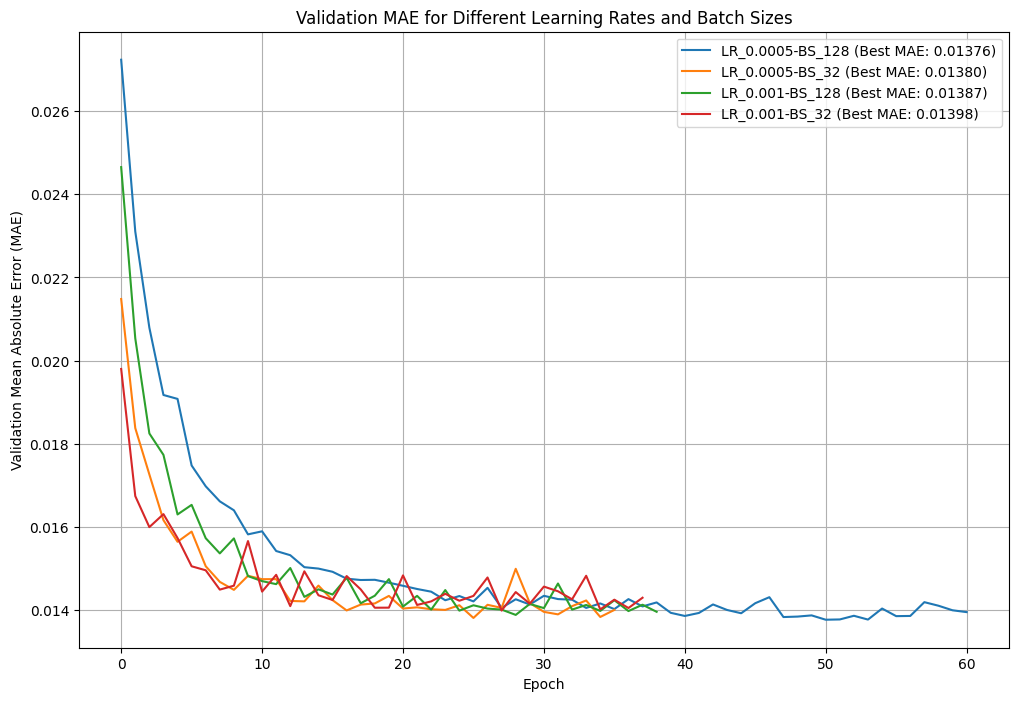

In [8]:
import matplotlib.pyplot as plt
import os
import time
from tensorflow.keras.optimizers import Adam
# --- Setup for the Learning Rate and Batch Size Tuning Experiment ---

# Define the hyperparameters we want to test
learning_rates_to_test = [0.001, 0.0005]
batch_sizes_to_test = [32, 128]

# Define our chosen model architecture (this is now fixed)
chosen_model_config = {'name': '2_LSTM_Medium', 'units': [64], 'dropout': 0.2}

# Store results for final comparison
final_tuning_log = {}

# --- Tuning Loop ---
for lr in learning_rates_to_test:
    for bs in batch_sizes_to_test:
        run_name = f"LR_{lr}-BS_{bs}"
        print(f"\n{'='*50}")
        print(f"--- TESTING: {run_name} ---")
        print(f"{'='*50}")
        
        start_time = time.time()

        # --- Build the Model ---
        model = Sequential()
        model.add(LSTM(
            units=chosen_model_config['units'][0],
            input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])
        ))
        model.add(Dropout(chosen_model_config['dropout']))
        model.add(Dense(y_train_reshaped.shape[1], activation='linear'))

        # --- Compile the Model with the specific learning rate ---
        optimizer = Adam(learning_rate=lr)
        model.compile(optimizer=optimizer, loss='mae')
        
        # --- Define Callbacks ---
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # --- Train the Model with the specific batch size ---
        history = model.fit(
            X_train_reshaped,
            y_train_reshaped,
            epochs=100,
            batch_size=bs,
            validation_data=(X_val_reshaped, y_val_reshaped),
            callbacks=[early_stopping],
            verbose=0 # Set to 0 to keep the output clean, change to 1 for more detail
        )
        
        # --- Log Results ---
        best_mae = min(history.history['val_loss'])
        final_tuning_log[run_name] = {'history': history, 'best_mae': best_mae}
        
        end_time = time.time()
        print(f"Finished in {end_time - start_time:.2f} seconds. Best Validation MAE: {best_mae:.5f}")


# --- Final Comparison Plot ---
plt.figure(figsize=(12, 8))
# Sort the results by best MAE to make the plot legend more readable
sorted_results = sorted(final_tuning_log.items(), key=lambda item: item[1]['best_mae'])

for run_name, result in sorted_results:
    plt.plot(result['history'].history['val_loss'], label=f'{run_name} (Best MAE: {result["best_mae"]:.5f})')

plt.title('Validation MAE for Different Learning Rates and Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Validation Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'lr_bs_comparison.png'))
plt.show()

Again, changin parameters does not really do anything so we'll just stick with those that lead to faster training.

Even using weights in the model does not seem to help at all...

Checking the importanc of using weather data. Seeing if it actually improves performance on validation set.

In [7]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import holidays
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

# --- Helper Function ---
def create_sequences(X, y, timesteps):
    """
    Reshapes the flat data into sequences for an LSTM.
    """
    X_out, y_out = [], []
    for i in range(len(X) - timesteps):
        X_out.append(X[i:(i + timesteps)])
        y_out.append(y[i + timesteps])
    return np.array(X_out), np.array(y_out)

# --- Setup for the Experiment ---
TIMESTEPS = 24
LONGEST_LAG = 168 # Define our longest lag period
BEST_LR = 0.001
BEST_BS = 128
TARGET_COLS = ['valeur_NO2', 'valeur_CO', 'valeur_O3', 'valeur_PM10', 'valeur_PM25']
WEATHER_COLS = ['temperature', 'relative_humidity', 'wind_speed', 'precipitation', 'wind_direction', 'shortwave_radiation']
output_dir = 'graphs'
os.makedirs(output_dir, exist_ok=True)

# --- Load Data ---
df_full = pd.read_csv('data/train_cleaned.csv', parse_dates=['id'], index_col='id')

# --- 1. Create Local Climatology Features ---
print("Creating local climatology weather features...")
df_full['hour'] = df_full.index.hour
df_full['dayofyear'] = df_full.index.dayofyear

split_date_dt = pd.to_datetime('2024-08-01')
historical_weather_data = df_full[df_full.index < split_date_dt]

climatology_map = historical_weather_data.groupby(['dayofyear', 'hour'])[WEATHER_COLS].mean().reset_index()

df_full = pd.merge(df_full.reset_index(), climatology_map, on=['dayofyear', 'hour'], how='left', suffixes=('', '_climatology'))
df_full = df_full.set_index('id').sort_index()
climatology_cols = [f'{col}_climatology' for col in WEATHER_COLS]
print("Climatology features created.")

# --- 2. Main Experiment Loop ---
final_results = {}

for use_weather in [False, True]:
    model_type = "With_Weather_Climatology" if use_weather else "No_Weather"
    print(f"\n{'='*50}\n--- RUNNING FORECAST SIMULATION: {model_type} ---\n{'='*50}")

    # --- Feature Engineering ---
    df_full['dayofweek'] = df_full.index.dayofweek
    df_full['month'] = df_full.index.month
    df_full['is_weekend'] = (df_full['dayofweek'] >= 5).astype(int)
    training_years = df_full.index.year.unique()
    fr_holidays = holidays.country_holidays('FR', years=training_years)
    df_full['is_holiday'] = df_full.index.normalize().isin(fr_holidays).astype(int)
    
    df_lagged = df_full.copy()
    for lag in [1, 24, 168]:
        for col in TARGET_COLS:
            df_lagged[f'{col}_lag_{lag}'] = df_lagged[col].shift(lag)
    
    df_model_ready = df_lagged.dropna()

    # --- Split and Scale ---
    train_df = df_model_ready[df_model_ready.index < split_date_dt]
    val_df = df_model_ready[df_model_ready.index >= split_date_dt]

    features_to_drop = TARGET_COLS + WEATHER_COLS + climatology_cols if not use_weather else TARGET_COLS + WEATHER_COLS
    X_train = train_df.drop(columns=features_to_drop)
    y_train = train_df[TARGET_COLS]
    y_val = val_df[TARGET_COLS]

    x_scaler = MinMaxScaler().fit(X_train)
    y_scaler = MinMaxScaler().fit(y_train)

    X_train_scaled = x_scaler.transform(X_train)
    y_train_scaled = y_scaler.transform(y_train)

    # --- Reshape and Train Model ---
    X_train_reshaped, y_train_reshaped = create_sequences(X_train_scaled, y_train_scaled, TIMESTEPS)
    
    model = Sequential([
        LSTM(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
        Dropout(0.2),
        Dense(5, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=BEST_LR), loss='mae')
    
    model.fit(X_train_reshaped, y_train_reshaped, epochs=25, batch_size=BEST_BS, verbose=0)
    
    # --- Recursive Forecasting on the Validation Set ---
    print(f"Generating recursive forecast for {len(y_val)} steps...")
    
    # --- FIX for IndexError: Initialize with a longer history ---
    history_buffer = train_df.tail(LONGEST_LAG)
    predictions = []

    for i in range(len(y_val)):
        # Use only the last TIMESTEPS rows for the LSTM input
        input_sequence = history_buffer.tail(TIMESTEPS)
        X_history = input_sequence.drop(columns=features_to_drop)
        X_history_scaled = x_scaler.transform(X_history)
        X_input = np.reshape(X_history_scaled, (1, TIMESTEPS, X_history_scaled.shape[1]))
        
        # Predict
        pred_scaled = model.predict(X_input, verbose=0)
        pred_inversed = y_scaler.inverse_transform(pred_scaled)
        predictions.append(pred_inversed[0])
        
        # Create the new row for the history
        new_pred_row = pd.DataFrame(pred_inversed, index=[y_val.index[i]], columns=TARGET_COLS)
        next_features = val_df.iloc[[i]].drop(columns=TARGET_COLS + WEATHER_COLS)
        new_row_combined = pd.concat([new_pred_row, next_features], axis=1)

        # Calculate lags for the new row using the full history buffer
        for lag in [1, 24, 168]:
            for col in TARGET_COLS:
                new_row_combined[f'{col}_lag_{lag}'] = history_buffer[col].iloc[-lag]
        
        # Append the complete new row to the buffer
        history_buffer = pd.concat([history_buffer, new_row_combined])
        
    predictions_df = pd.DataFrame(predictions, index=y_val.index, columns=TARGET_COLS)
    
    # --- Calculate and Store Final MAE ---
    final_mae = mean_absolute_error(y_val, predictions_df)
    final_results[model_type] = final_mae
    print(f"--- Final Forecast MAE for {model_type}: {final_mae:.5f} ---")

# --- Final Comparison ---
print("\n--- EXPERIMENT RESULTS ---")
for model_type, mae in final_results.items():
    print(f"Final Recursive Forecast MAE for {model_type}: {mae:.5f}")

Creating local climatology weather features...
Climatology features created.

--- RUNNING FORECAST SIMULATION: No_Weather ---


/var/folders/ly/jbjk3dpx4r720krzm_3_dy700000gn/T/ipykernel_3619/2198590504.py:66: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_full['is_holiday'] = df_full.index.normalize().isin(fr_holidays).astype(int)
/Users/felix_myu/Desktop/HEC/paris_air_quality/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Generating recursive forecast for 815 steps...
--- Final Forecast MAE for No_Weather: 84.40260 ---

--- RUNNING FORECAST SIMULATION: With_Weather_Climatology ---


/var/folders/ly/jbjk3dpx4r720krzm_3_dy700000gn/T/ipykernel_3619/2198590504.py:66: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_full['is_holiday'] = df_full.index.normalize().isin(fr_holidays).astype(int)
/Users/felix_myu/Desktop/HEC/paris_air_quality/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Generating recursive forecast for 815 steps...
--- Final Forecast MAE for With_Weather_Climatology: 46.62537 ---

--- EXPERIMENT RESULTS ---
Final Recursive Forecast MAE for No_Weather: 84.40260
Final Recursive Forecast MAE for With_Weather_Climatology: 46.62537


Interestingly enough, the weather does seem to have a strong impact on performance. Even when using just average over rolling 2 weeks for all 4 years.

In [8]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import holidays
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os
from tqdm import tqdm # Import tqdm for the progress bar

# --- Helper Function ---
def create_sequences(X, y, timesteps):
    """
    Reshapes the flat data into sequences for an LSTM.
    """
    X_out, y_out = [], []
    for i in range(len(X) - timesteps):
        X_out.append(X[i:(i + timesteps)])
        y_out.append(y[i + timesteps])
    return np.array(X_out), np.array(y_out)

# --- Setup for the Experiment ---
TIMESTEPS = 24
LONGEST_LAG = 168
BEST_LR = 0.001
BEST_BS = 128
TARGET_COLS = ['valeur_NO2', 'valeur_CO', 'valeur_O3', 'valeur_PM10', 'valeur_PM25']
WEATHER_COLS = ['temperature', 'relative_humidity', 'wind_speed', 'precipitation', 'wind_direction', 'shortwave_radiation']
output_dir = 'graphs'
os.makedirs(output_dir, exist_ok=True)

# --- 1. Load Data and Perform ALL Feature Engineering ONCE ---
print("--- Starting Data Preparation ---")
df_full = pd.read_csv('data/train_cleaned.csv', parse_dates=['id'], index_col='id')

# Create deterministic time features
df_full['hour'] = df_full.index.hour
df_full['dayofyear'] = df_full.index.dayofyear
df_full['dayofweek'] = df_full.index.dayofweek
df_full['month'] = df_full.index.month
df_full['is_weekend'] = (df_full['dayofweek'] >= 5).astype(int)
training_years = df_full.index.year.unique()
fr_holidays = holidays.country_holidays('FR', years=training_years)
df_full['is_holiday'] = df_full.index.normalize().isin(fr_holidays).astype(int)

# Create Local Climatology Features
print("Creating local climatology weather features...")
split_date_dt = pd.to_datetime('2024-08-01')
historical_weather_data = df_full[df_full.index < split_date_dt]
climatology_map = historical_weather_data.groupby(['dayofyear', 'hour'])[WEATHER_COLS].mean().reset_index()
df_full = pd.merge(df_full.reset_index(), climatology_map, on=['dayofyear', 'hour'], how='left', suffixes=('', '_climatology'))
df_full = df_full.set_index('id').sort_index()
climatology_cols = [f'{col}_climatology' for col in WEATHER_COLS]

# --- FIX #2: Handle potential NaNs from merge ---
for col in climatology_cols:
    global_mean = historical_weather_data[col.replace('_climatology', '')].mean()
    df_full[col].fillna(global_mean, inplace=True)
print("Climatology features created and NaNs handled.")

# Create Lagged Features
print("Creating lagged pollutant features...")
df_lagged = df_full.copy()
for lag in [1, 24, 168]:
    for col in TARGET_COLS:
        df_lagged[f'{col}_lag_{lag}'] = df_lagged[col].shift(lag)

df_model_ready = df_lagged.dropna()
print("--- Data Preparation Complete ---")

# --- 2. Main Experiment Loop ---
final_results = {}
for use_weather in [False, True]:
    model_type = "With_Weather_Climatology" if use_weather else "No_Weather"
    print(f"\n{'='*50}\n--- RUNNING FORECAST SIMULATION: {model_type} ---\n{'='*50}")

    # --- Split and Scale ---
    train_df = df_model_ready[df_model_ready.index < split_date_dt]
    val_df = df_model_ready[df_model_ready.index >= split_date_dt]

    # Define features to drop based on the experiment
    features_to_drop = TARGET_COLS + WEATHER_COLS + climatology_cols if not use_weather else TARGET_COLS + WEATHER_COLS
    
    X_train = train_df.drop(columns=features_to_drop)
    y_train = train_df[TARGET_COLS]
    y_val = val_df[TARGET_COLS]

    x_scaler = MinMaxScaler().fit(X_train)
    y_scaler = MinMaxScaler().fit(y_train)
    X_train_scaled = x_scaler.transform(X_train)
    y_train_scaled = y_scaler.transform(y_train)

    # --- Reshape and Train Model ---
    X_train_reshaped, y_train_reshaped = create_sequences(X_train_scaled, y_train_scaled, TIMESTEPS)
    
    model = Sequential([
        LSTM(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
        Dropout(0.2),
        Dense(5, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=BEST_LR), loss='mae')
    
    print("Training model...")
    model.fit(X_train_reshaped, y_train_reshaped, epochs=25, batch_size=BEST_BS, verbose=0)
    
    # --- Recursive Forecasting on the Validation Set ---
    history_buffer = train_df.tail(LONGEST_LAG)
    predictions = []

    # --- NEW: Added tqdm for progress visualization ---
    for i in tqdm(range(len(y_val)), desc=f"Forecasting {model_type}"):
        input_sequence = history_buffer.tail(TIMESTEPS)
        X_history = input_sequence.drop(columns=features_to_drop)
        X_history_scaled = x_scaler.transform(X_history)
        X_input = np.reshape(X_history_scaled, (1, TIMESTEPS, X_history_scaled.shape[1]))
        
        pred_scaled = model.predict(X_input, verbose=0)
        pred_inversed = y_scaler.inverse_transform(pred_scaled)
        predictions.append(pred_inversed[0])
        
        new_pred_row = pd.DataFrame(pred_inversed, index=[y_val.index[i]], columns=TARGET_COLS)
        next_features = val_df.iloc[[i]].drop(columns=TARGET_COLS + WEATHER_COLS)
        new_row_combined = pd.concat([new_pred_row, next_features], axis=1)

        for lag in [1, 24, 168]:
            for col in TARGET_COLS:
                new_row_combined[f'{col}_lag_{lag}'] = history_buffer[col].iloc[-lag]
        
        # --- FIX #1: Correctly update the history buffer ---
        history_buffer = pd.concat([history_buffer.iloc[1:], new_row_combined])
        
    predictions_df = pd.DataFrame(predictions, index=y_val.index, columns=TARGET_COLS)
    
    # --- Calculate and Store Final MAE ---
    final_mae = mean_absolute_error(y_val, predictions_df)
    final_results[model_type] = final_mae
    print(f"--- Final Forecast MAE for {model_type}: {final_mae:.5f} ---")

# --- Final Comparison ---
print("\n--- EXPERIMENT RESULTS ---")
for model_type, mae in final_results.items():
    print(f"Final Recursive Forecast MAE for {model_type}: {mae:.5f}")

--- Starting Data Preparation ---
Creating local climatology weather features...
Climatology features created and NaNs handled.
Creating lagged pollutant features...
--- Data Preparation Complete ---

--- RUNNING FORECAST SIMULATION: No_Weather ---
Training model...


/var/folders/ly/jbjk3dpx4r720krzm_3_dy700000gn/T/ipykernel_3619/2787120741.py:48: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_full['is_holiday'] = df_full.index.normalize().isin(fr_holidays).astype(int)
/var/folders/ly/jbjk3dpx4r720krzm_3_dy700000gn/T/ipykernel_3619/2787120741.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original 

--- Final Forecast MAE for No_Weather: 90.71215 ---

--- RUNNING FORECAST SIMULATION: With_Weather_Climatology ---
Training model...


Forecasting With_Weather_Climatology: 100%|██████████| 815/815 [00:22<00:00, 36.81it/s]

--- Final Forecast MAE for With_Weather_Climatology: 97.05745 ---

--- EXPERIMENT RESULTS ---
Final Recursive Forecast MAE for No_Weather: 90.71215
Final Recursive Forecast MAE for With_Weather_Climatology: 97.05745
